# 03. Embedding Pipeline - Chunking & Vector Generation

This notebook demonstrates the complete embedding pipeline: semantic chunking and vector embedding generation.

## Objectives:
- Load processed documents from Phase 2
- Apply semantic-hierarchical chunking strategies
- Generate embeddings using Google Gemini
- Analyze chunk distribution and embedding quality
- Prepare data for vector storage in Phase 3

## Chunking Strategy:
- **Semantic-Hierarchical**: Respects document structure (headers, sections)
- **Code Preservation**: Keeps code blocks intact
- **Context Overlap**: Maintains continuity between chunks
- **Size Optimization**: Target 1200 tokens with 200 token overlap

## 1. Environment Setup

In [1]:
import sys
import os
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import logging
from tqdm import tqdm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Add src to path
project_root = Path.cwd().parent
src_path = project_root / "src"
sys.path.insert(0, str(src_path))

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

print(f"📁 Project root: {project_root}")
print(f"📂 Source path: {src_path}")

📁 Project root: /Users/sourangshupal/Documents/projects/langchain-rag-project
📂 Source path: /Users/sourangshupal/Documents/projects/langchain-rag-project/src


In [2]:
# Import our modules
from src.chunking.text_splitter import DocumentChunker, SemanticHierarchicalChunker, chunk_langchain_documents
from src.embedding.embedding_generator import GeminiEmbeddingGenerator, EmbeddingPipeline, generate_embeddings_for_chunks
from src.ingestion.data_pipeline import DataIngestionPipeline
from src.config import settings

print("✅ Successfully imported chunking and embedding modules")
print(f"⚙️  Chunk size: {settings.chunk_size} tokens")
print(f"⚙️  Chunk overlap: {settings.chunk_overlap} tokens")
print(f"🤖 Embedding model: {settings.embedding_model}")

✅ Successfully imported chunking and embedding modules
⚙️  Chunk size: 1200 tokens
⚙️  Chunk overlap: 200 tokens
🤖 Embedding model: gemini-embedding-001


## 2. Load Processed Documents

In [3]:
# Load processed documents from Phase 2
pipeline = DataIngestionPipeline()
processed_dir = project_root / "notebooks" / "data" / "processed3"

print("📂 Loading processed documents...")

# Check if processed documents exist
document_files = list(processed_dir.glob("*_documents.json"))

if not document_files:
    print("❌ No processed documents found!")
    print("Please run notebook 02_data_ingestion.ipynb first.")
    documents_loaded = False
else:
    print(f"📄 Found {len(document_files)} document files:")
    for file in document_files:
        print(f"   {file.name}")
    
    # Load all documents
    processed_documents = {}
    total_docs = 0
    
    for file_path in document_files:
        doc_type = file_path.stem.replace('_documents', '')
        
        with open(file_path, 'r', encoding='utf-8') as f:
            docs = json.load(f)
            processed_documents[doc_type] = docs
            total_docs += len(docs)
            print(f"   📋 {doc_type}: {len(docs)} documents")
    
    print(f"\n✅ Loaded {total_docs} documents across {len(processed_documents)} types")
    documents_loaded = True

📂 Loading processed documents...
📄 Found 5 document files:
   rst_files_documents.json
   python_files_documents.json
   notebooks_documents.json
   readme_files_documents.json
   markdown_documents.json
   📋 rst_files: 2 documents
   📋 python_files: 388 documents
   📋 notebooks: 305 documents
   📋 readme_files: 11 documents
   📋 markdown: 119 documents

✅ Loaded 825 documents across 5 types


## 3. Chunking Strategy Analysis

In [4]:
# Test chunking on sample documents
if documents_loaded:
    print("🔍 Analyzing chunking strategies...\n")
    
    # Initialize chunker
    chunker = DocumentChunker(strategy="semantic_hierarchical")
    
    # Test different document types
    sample_results = []
    
    for doc_type, docs in processed_documents.items():
        if not docs:
            continue
            
        # Test first document of each type
        sample_doc = docs[0]
        print(f"🧩 Testing chunking on {doc_type}: {sample_doc['metadata']['file_name']}")
        print(f"   Original length: {len(sample_doc['content']):,} characters")
        
        # Chunk the document
        chunks = chunker.chunk_document(sample_doc)
        
        if chunks:
            chunk_sizes = [chunk['metadata']['chunk_size'] for chunk in chunks]
            token_counts = [chunk['metadata']['token_count'] for chunk in chunks]
            
            print(f"   ✅ Generated {len(chunks)} chunks")
            print(f"   📏 Avg chunk size: {np.mean(chunk_sizes):.0f} chars ({np.mean(token_counts):.0f} tokens)")
            print(f"   📊 Size range: {min(chunk_sizes)}-{max(chunk_sizes)} chars")
            print(f"   🎯 Target efficiency: {(np.mean(token_counts)/settings.chunk_size)*100:.1f}%\n")
            
            sample_results.append({
                'doc_type': doc_type,
                'original_length': len(sample_doc['content']),
                'num_chunks': len(chunks),
                'avg_chunk_size': np.mean(chunk_sizes),
                'avg_tokens': np.mean(token_counts),
                'chunks': chunks[:2]  # Store first 2 chunks for inspection
            })
        else:
            print(f"   ❌ Failed to generate chunks\n")
    
    print(f"✅ Tested chunking on {len(sample_results)} document types")
else:
    print("⚠️  Skipping chunking analysis - no documents loaded")

🔍 Analyzing chunking strategies...

🧩 Testing chunking on rst_files: README.rst
   Original length: 834 characters
   ✅ Generated 2 chunks
   📏 Avg chunk size: 416 chars (105 tokens)
   📊 Size range: 374-458 chars
   🎯 Target efficiency: 8.8%

🧩 Testing chunking on python_files: create_api_rst.py
   Original length: 16,620 characters
   ✅ Generated 116 chunks
   📏 Avg chunk size: 141 chars (36 tokens)
   📊 Size range: 5-3306 chars
   🎯 Target efficiency: 3.0%

🧩 Testing chunking on notebooks: output_parser_string.ipynb
   Original length: 2,489 characters
   ✅ Generated 1 chunks
   📏 Avg chunk size: 2489 chars (566 tokens)
   📊 Size range: 2489-2489 chars
   🎯 Target efficiency: 47.2%

🧩 Testing chunking on readme_files: README.md
   Original length: 2,980 characters
   ✅ Generated 3 chunks
   📏 Avg chunk size: 759 chars (147 tokens)
   📊 Size range: 574-1036 chars
   🎯 Target efficiency: 12.2%

🧩 Testing chunking on markdown: README.md
   Original length: 126 characters
   ✅ Generated

In [5]:
# Show sample chunks for inspection
if documents_loaded and sample_results:
    print("🔍 Sample chunks for inspection:\n")
    
    for result in sample_results[:2]:  # Show first 2 doc types
        print(f"📋 {result['doc_type'].upper()} - Sample Chunk:")
        print("=" * 50)
        
        if result['chunks']:
            sample_chunk = result['chunks'][0]
            content_preview = sample_chunk['content'][:500] + "..." if len(sample_chunk['content']) > 500 else sample_chunk['content']
            
            print(f"📊 Metadata:")
            print(f"   Size: {sample_chunk['metadata']['chunk_size']} chars")
            print(f"   Tokens: {sample_chunk['metadata']['token_count']}")
            print(f"   Index: {sample_chunk['metadata']['chunk_index']}")
            
            print(f"\n📝 Content preview:")
            print(content_preview)
            print("\n" + "=" * 50 + "\n")
else:
    print("⚠️  No sample results to display")

🔍 Sample chunks for inspection:

📋 RST_FILES - Sample Chunk:
📊 Metadata:
   Size: 458 chars
   Tokens: 105
   Index: 0

📝 Content preview:
# Example Docs

The sample docs directory contains the following files:

• example-10k.html - A 10-K SEC filing in HTML format

• layout-parser-paper.pdf - A PDF copy of the layout parser paper

• factbook.xml/factbook.xsl - Example XML/XLS files that you can use to test stylesheets

These documents can be used to test out the parsers in the library. In addition, here are instructions for pulling in some sample docs that are too big to store in the repo.


📋 PYTHON_FILES - Sample Chunk:
📊 Metadata:
   Size: 383 chars
   Tokens: 74
   Index: 0

📝 Content preview:
# """Script for auto

generating api_reference.rst."""

import importlib import inspect import os import sys import typing from enum import Enum from pathlib import Path from typing import Dict, List, Literal, Optional, Sequence, TypedDict, Union

import toml import typing_extensions from la

## 4. Full Document Chunking

In [6]:
# Chunk all documents
if documents_loaded:
    print("🚀 Starting full document chunking...\n")
    print("This may take several minutes for large document sets.")
    
    # Chunk all documents
    chunked_documents = chunk_langchain_documents(processed_documents)
    
    # Calculate comprehensive statistics
    total_chunks = sum(len(chunks) for chunks in chunked_documents.values())
    total_original_docs = sum(len(docs) for docs in processed_documents.values())
    
    print(f"\n🎉 Chunking completed successfully!")
    print(f"📊 Summary: {total_original_docs} documents → {total_chunks} chunks")
    
    # Detailed breakdown by document type
    print(f"\n📋 Chunks by document type:")
    for doc_type, chunks in chunked_documents.items():
        original_count = len(processed_documents.get(doc_type, []))
        chunk_count = len(chunks)
        ratio = chunk_count / original_count if original_count > 0 else 0
        print(f"   {doc_type}: {original_count} docs → {chunk_count} chunks (avg {ratio:.1f} chunks/doc)")
    
    chunking_completed = True
else:
    print("⚠️  Skipping chunking - no documents loaded")
    chunking_completed = False

INFO: Chunking 2 rst_files documents...
INFO: Completed chunking: 2 documents → 3 chunks
INFO:   rst_files: 3 chunks, avg size: 338 chars, 85 tokens
INFO: Chunking 388 python_files documents...
INFO: Chunked 100/388 documents, 483 total chunks
INFO: Chunked 200/388 documents, 699 total chunks
INFO: Chunked 300/388 documents, 950 total chunks
INFO: Completed chunking: 388 documents → 1132 chunks
INFO:   python_files: 1132 chunks, avg size: 581 chars, 136 tokens
INFO: Chunking 305 notebooks documents...


🚀 Starting full document chunking...

This may take several minutes for large document sets.


INFO: Chunked 100/305 documents, 999 total chunks
INFO: Chunked 200/305 documents, 1733 total chunks
INFO: Chunked 300/305 documents, 1854 total chunks
INFO: Completed chunking: 305 documents → 1861 chunks
INFO:   notebooks: 1861 chunks, avg size: 1029 chars, 254 tokens
INFO: Chunking 11 readme_files documents...
INFO: Completed chunking: 11 documents → 40 chunks
INFO:   readme_files: 40 chunks, avg size: 723 chars, 149 tokens
INFO: Chunking 119 markdown documents...
INFO: Chunked 100/119 documents, 2889 total chunks
INFO: Completed chunking: 119 documents → 3086 chunks
INFO:   markdown: 3086 chunks, avg size: 246 chars, 58 tokens



🎉 Chunking completed successfully!
📊 Summary: 825 documents → 6122 chunks

📋 Chunks by document type:
   rst_files: 2 docs → 3 chunks (avg 1.5 chunks/doc)
   python_files: 388 docs → 1132 chunks (avg 2.9 chunks/doc)
   notebooks: 305 docs → 1861 chunks (avg 6.1 chunks/doc)
   readme_files: 11 docs → 40 chunks (avg 3.6 chunks/doc)
   markdown: 119 docs → 3086 chunks (avg 25.9 chunks/doc)


## 5. Chunking Quality Analysis

In [7]:
# Analyze chunk quality and distribution
if chunking_completed:
    print("📊 Analyzing chunk quality and distribution...\n")
    
    # Collect all chunk statistics
    all_chunks = []
    for doc_type, chunks in chunked_documents.items():
        for chunk in chunks:
            chunk_stats = {
                'doc_type': doc_type,
                'chunk_size': chunk['metadata']['chunk_size'],
                'token_count': chunk['metadata']['token_count'],
                'chunk_index': chunk['metadata']['chunk_index'],
                'source_doc_type': chunk['metadata'].get('doc_type', 'unknown')
            }
            all_chunks.append(chunk_stats)
    
    # Convert to DataFrame for analysis
    chunk_df = pd.DataFrame(all_chunks)
    
    print(f"📈 Chunk Statistics:")
    print(f"   Total chunks: {len(chunk_df):,}")
    print(f"   Avg chunk size: {chunk_df['chunk_size'].mean():.0f} characters")
    print(f"   Avg token count: {chunk_df['token_count'].mean():.0f} tokens")
    print(f"   Median token count: {chunk_df['token_count'].median():.0f} tokens")
    print(f"   Token count std: {chunk_df['token_count'].std():.0f} tokens")
    
    # Quality metrics
    target_tokens = settings.chunk_size
    within_target = ((chunk_df['token_count'] >= target_tokens * 0.7) & 
                    (chunk_df['token_count'] <= target_tokens * 1.2))
    
    print(f"\n🎯 Quality Metrics:")
    print(f"   Chunks within target range (70-120% of {target_tokens}): {within_target.sum():,} ({within_target.mean()*100:.1f}%)")
    print(f"   Very small chunks (<100 tokens): {(chunk_df['token_count'] < 100).sum():,}")
    print(f"   Very large chunks (>2000 tokens): {(chunk_df['token_count'] > 2000).sum():,}")
    
    # Token efficiency (how well we're using the token budget)
    efficiency = chunk_df['token_count'].mean() / target_tokens
    print(f"   Token efficiency: {efficiency*100:.1f}% (higher is better, target ~80-90%)")
else:
    print("⚠️  Skipping quality analysis - chunking not completed")
    chunk_df = None

📊 Analyzing chunk quality and distribution...

📈 Chunk Statistics:
   Total chunks: 6,122
   Avg chunk size: 549 characters
   Avg token count: 133 tokens
   Median token count: 38 tokens
   Token count std: 652 tokens

🎯 Quality Metrics:
   Chunks within target range (70-120% of 1200): 158 (2.6%)
   Very small chunks (<100 tokens): 4,068
   Very large chunks (>2000 tokens): 2
   Token efficiency: 11.1% (higher is better, target ~80-90%)


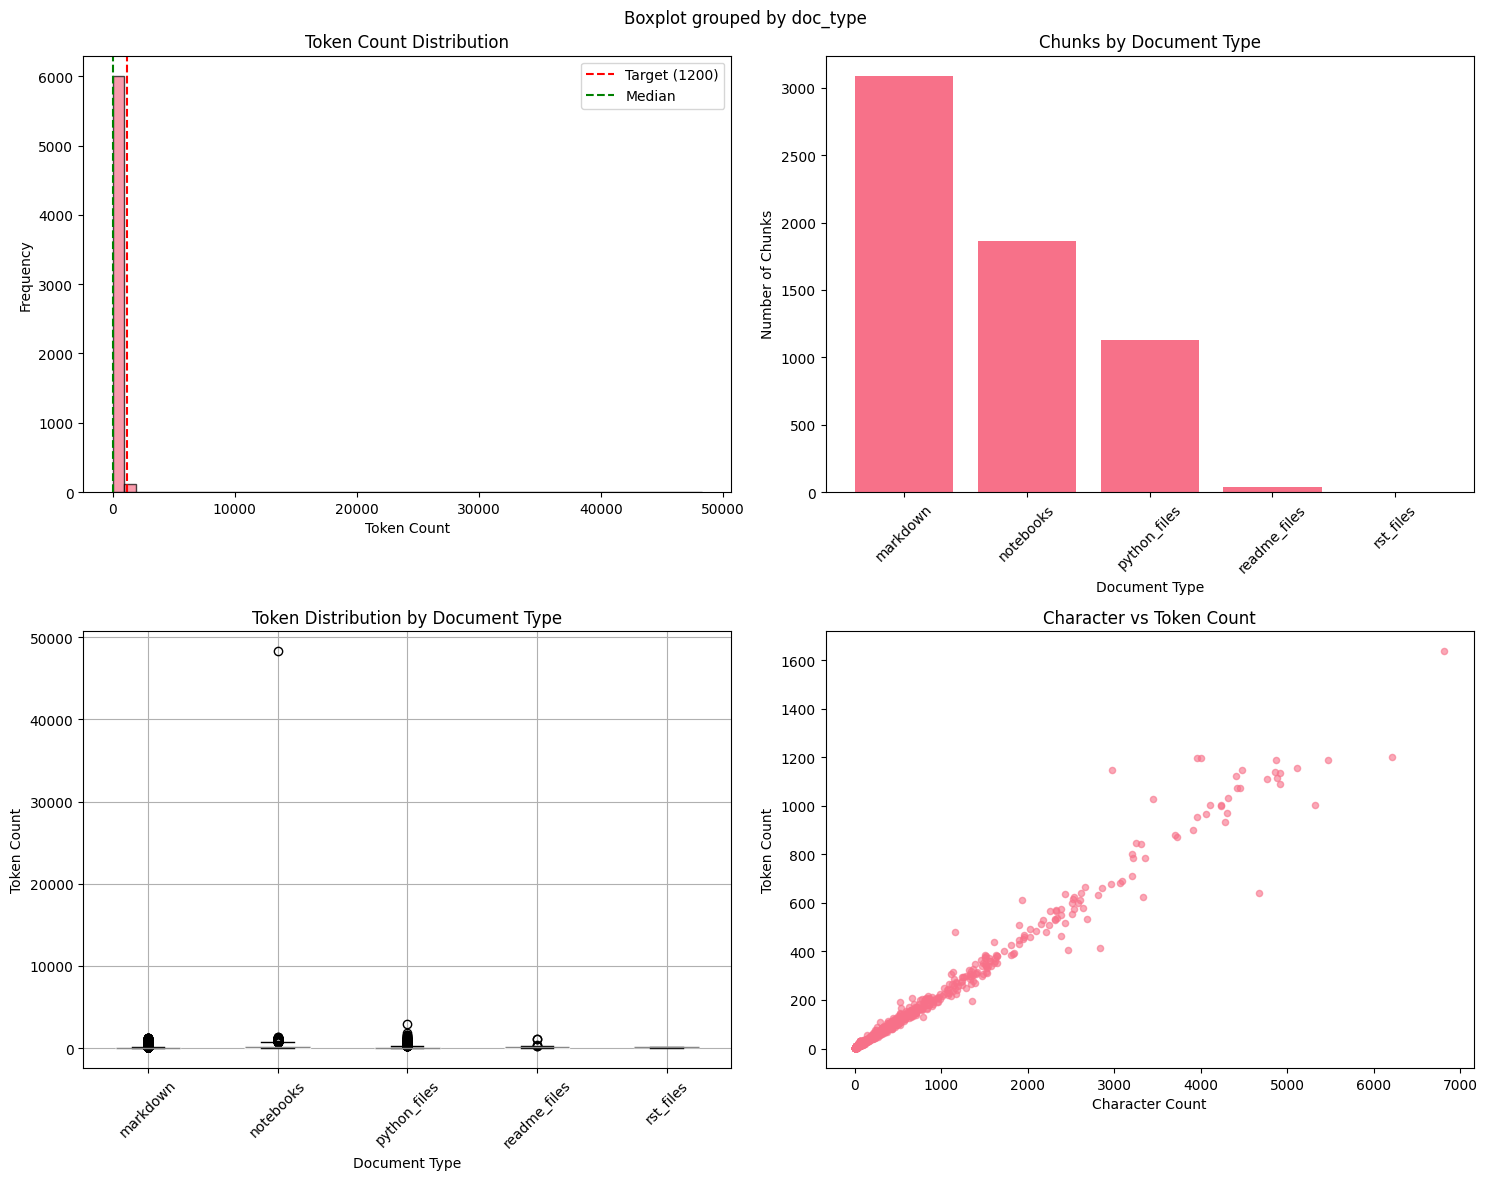


📋 Summary by Document Type:
              Count  Avg Tokens  Median Tokens  Token Std  Avg Chars
doc_type                                                            
markdown       3086       57.96           15.0     128.12     246.26
notebooks      1861      254.20          138.0    1144.23    1029.01
python_files   1132      136.49           46.0     248.39     580.54
readme_files     40      149.45           89.0     242.41     723.20
rst_files         3       85.00          105.0      34.64     338.33


In [8]:
# Visualize chunk distribution
if chunk_df is not None and len(chunk_df) > 0:
    # Set up plotting
    plt.style.use('default')
    sns.set_palette("husl")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Chunk Distribution Analysis', fontsize=16, fontweight='bold')
    
    # 1. Token count distribution
    axes[0, 0].hist(chunk_df['token_count'], bins=50, alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(settings.chunk_size, color='red', linestyle='--', label=f'Target ({settings.chunk_size})')
    axes[0, 0].axvline(chunk_df['token_count'].median(), color='green', linestyle='--', label='Median')
    axes[0, 0].set_title('Token Count Distribution')
    axes[0, 0].set_xlabel('Token Count')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    
    # 2. Chunks by document type
    doc_type_counts = chunk_df['doc_type'].value_counts()
    axes[0, 1].bar(doc_type_counts.index, doc_type_counts.values)
    axes[0, 1].set_title('Chunks by Document Type')
    axes[0, 1].set_xlabel('Document Type')
    axes[0, 1].set_ylabel('Number of Chunks')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Token count by document type (box plot)
    chunk_df.boxplot(column='token_count', by='doc_type', ax=axes[1, 0])
    axes[1, 0].set_title('Token Distribution by Document Type')
    axes[1, 0].set_xlabel('Document Type')
    axes[1, 0].set_ylabel('Token Count')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 4. Character vs Token relationship
    sample_chunks = chunk_df.sample(min(1000, len(chunk_df)))  # Sample for performance
    scatter = axes[1, 1].scatter(sample_chunks['chunk_size'], sample_chunks['token_count'], 
                               alpha=0.6, s=20)
    axes[1, 1].set_title('Character vs Token Count')
    axes[1, 1].set_xlabel('Character Count')
    axes[1, 1].set_ylabel('Token Count')
    
    plt.tight_layout()
    plt.show()
    
    # Summary table by document type
    print("\n📋 Summary by Document Type:")
    summary = chunk_df.groupby('doc_type').agg({
        'token_count': ['count', 'mean', 'median', 'std'],
        'chunk_size': 'mean'
    }).round(2)
    
    summary.columns = ['Count', 'Avg Tokens', 'Median Tokens', 'Token Std', 'Avg Chars']
    print(summary)
else:
    print("⚠️  No chunk data available for visualization")

## 6. Embedding Generation

In [9]:
# Test embedding generation on a small sample first
if chunking_completed:
    print("🧪 Testing embedding generation with sample chunks...\n")
    
    # Take small sample for testing
    test_chunks = []
    for doc_type, chunks in chunked_documents.items():
        if chunks:
            test_chunks.extend(chunks[:2])  # Take 2 chunks per type
    
    print(f"🔬 Testing with {len(test_chunks)} sample chunks...")
    
    # Initialize embedding generator
    try:
        embedding_generator = GeminiEmbeddingGenerator()
        print("✅ Gemini embedding generator initialized")
        
        # Test single embedding
        test_text = test_chunks[0]['content'][:500]  # First 500 chars
        print(f"\n🧪 Testing single embedding...")
        print(f"   Text length: {len(test_text)} characters")
        
        test_embedding = embedding_generator.generate_embedding(test_text)
        
        if test_embedding:
            print(f"✅ Embedding generated successfully!")
            print(f"   Dimension: {len(test_embedding)}")
            print(f"   Sample values: {test_embedding[:5]}...")
            
            # Test batch generation with sample
            print(f"\n🔄 Testing batch embedding generation...")
            sample_embedded = embedding_generator.embed_chunks(test_chunks[:3])
            
            if sample_embedded:
                print(f"✅ Batch embedding successful!")
                print(f"   Generated {len(sample_embedded)} embeddings")
                print(f"   Embedding dimension: {len(sample_embedded[0]['embedding'])}")
                embedding_test_passed = True
            else:
                print(f"❌ Batch embedding failed")
                embedding_test_passed = False
        else:
            print(f"❌ Single embedding failed")
            embedding_test_passed = False
            
    except Exception as e:
        print(f"❌ Embedding generator initialization failed: {str(e)}")
        print("Please check your Google API key in .env file")
        embedding_test_passed = False
else:
    print("⚠️  Skipping embedding test - chunking not completed")
    embedding_test_passed = False

🧪 Testing embedding generation with sample chunks...

🔬 Testing with 10 sample chunks...


INFO: HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"
INFO: ✅ Gemini API connection successful
INFO: 📐 Embedding dimension: 3072
INFO: 📂 Loaded 1833 embeddings from cache
INFO: 🚀 Generating embeddings for 3 chunks...


✅ Gemini embedding generator initialized

🧪 Testing single embedding...
   Text length: 458 characters
✅ Embedding generated successfully!
   Dimension: 3072
   Sample values: [0.016131474, 0.0067131035, 0.009185435, -0.055640046, -0.0057059187]...

🔄 Testing batch embedding generation...


Generating embeddings: 100%|██████████| 3/3 [00:03<00:00,  1.05s/it]
INFO: ✅ Generated 3 embeddings (0 failed)


✅ Batch embedding successful!
   Generated 3 embeddings
   Embedding dimension: 3072


In [10]:
# Generate embeddings for all chunks
if chunking_completed and embedding_test_passed:
    print("🚀 Starting full embedding generation...\n")
    print("⏰ This will take several minutes depending on the number of chunks.")
    print("💡 Progress will be shown during generation.\n")
    
    # Estimate time based on chunk count
    total_chunks = sum(len(chunks) for chunks in chunked_documents.values())
    estimated_minutes = (total_chunks * 0.15) / 60  # ~0.15 seconds per embedding
    print(f"📊 Embedding {total_chunks:,} chunks (estimated time: {estimated_minutes:.1f} minutes)\n")
    
    # Generate embeddings using the pipeline
    embedding_result = generate_embeddings_for_chunks(chunked_documents)
    
    if embedding_result["success"]:
        print("\n🎉 Embedding generation completed successfully!")
        
        # Display results
        pipeline_stats = embedding_result["pipeline_stats"]
        generator_stats = embedding_result["generator_stats"]
        
        print(f"\n📊 Pipeline Summary:")
        print(f"   Total chunks processed: {pipeline_stats['total_chunks']:,}")
        print(f"   Successful embeddings: {pipeline_stats['successful_embeddings']:,}")
        print(f"   Failed embeddings: {pipeline_stats['failed_embeddings']:,}")
        print(f"   Success rate: {(pipeline_stats['successful_embeddings']/pipeline_stats['total_chunks'])*100:.1f}%")
        print(f"   Embedding dimension: {pipeline_stats['embedding_dimension']}")
        
        print(f"\n📈 Generator Statistics:")
        print(f"   Total cached embeddings: {generator_stats['total_embeddings']:,}")
        print(f"   Model: {generator_stats['model_name']}")
        print(f"   Cache size: {generator_stats['cache_size_mb']:.1f} MB")
        
        print(f"\n💾 Output files saved to: {project_root}/data/embeddings/")
        embedded_documents = embedding_result["embedded_documents"]
        embedding_generation_completed = True
    else:
        print(f"❌ Embedding generation failed: {embedding_result.get('error', 'Unknown error')}")
        embedding_generation_completed = False
else:
    if not chunking_completed:
        print("⚠️  Skipping embedding generation - chunking not completed")
    elif not embedding_test_passed:
        print("⚠️  Skipping embedding generation - embedding test failed")
    embedding_generation_completed = False

🚀 Starting full embedding generation...

⏰ This will take several minutes depending on the number of chunks.
💡 Progress will be shown during generation.

📊 Embedding 6,122 chunks (estimated time: 15.3 minutes)



INFO: HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"
INFO: ✅ Gemini API connection successful
INFO: 📐 Embedding dimension: 3072
INFO: 📂 Loaded 1833 embeddings from cache
INFO: 🔄 Processing 3 rst_files chunks...
INFO: 🚀 Generating embeddings for 3 chunks...
Generating embeddings: 100%|██████████| 3/3 [00:03<00:00,  1.05s/it]
INFO: ✅ Generated 3 embeddings (0 failed)
INFO: 💾 Saved 3 embedded rst_files chunks
INFO: 🔄 Processing 1132 python_files chunks...
INFO: 🚀 Generating embeddings for 1132 chunks...
Generating embeddings: 100%|██████████| 1132/1132 [02:22<00:00,  7.96it/s]
INFO: ✅ Generated 1132 embeddings (0 failed)
INFO: 💾 Saved 1132 embedded python_files chunks
INFO: 🔄 Processing 1861 notebooks chunks...
INFO: 🚀 Generating embeddings for 1861 chunks...
Generating embeddings: 100%|██████████| 1861/1861 [12:11<00:00,  2.54it/s]
INFO: ✅ Generated 1861 embeddings (0 failed)
INFO: 💾 Saved 1861 embedded


🎉 Embedding generation completed successfully!

📊 Pipeline Summary:
   Total chunks processed: 6,122
   Successful embeddings: 6,122
   Failed embeddings: 0
   Success rate: 100.0%
   Embedding dimension: 3072

📈 Generator Statistics:
   Total cached embeddings: 5,071
   Model: gemini-embedding-001
   Cache size: 204.3 MB

💾 Output files saved to: /Users/sourangshupal/Documents/projects/langchain-rag-project/data/embeddings/


## 7. Embedding Quality Analysis

In [ ]:
# Analyze embedding quality and characteristics
if embedding_generation_completed:
    print("🔍 Analyzing embedding quality and characteristics...\n")
    
    # Collect embedding statistics
    embedding_stats = []
    all_embeddings = []
    
    for doc_type, chunks in embedded_documents.items():
        for chunk in chunks:
            if 'embedding' in chunk:
                embedding = np.array(chunk['embedding'])
                all_embeddings.append(embedding)
                
                stats = {
                    'doc_type': doc_type,
                    'embedding_norm': np.linalg.norm(embedding),
                    'embedding_mean': np.mean(embedding),
                    'embedding_std': np.std(embedding),
                    'token_count': chunk['metadata']['token_count'],
                    'chunk_size': chunk['metadata']['chunk_size']
                }
                embedding_stats.append(stats)
    
    if embedding_stats:
        embedding_df = pd.DataFrame(embedding_stats)
        print(f"📊 Embedding Quality Metrics:")
        print(f"   Total embeddings: {len(embedding_stats):,}")
        print(f"   Avg embedding norm: {embedding_df['embedding_norm'].mean():.4f}")
        print(f"   Embedding norm std: {embedding_df['embedding_norm'].std():.4f}")
        print(f"   Avg embedding mean: {embedding_df['embedding_mean'].mean():.6f}")
        print(f"   Avg embedding std: {embedding_df['embedding_std'].mean():.4f}")
        
        # Check for potential issues
        zero_embeddings = (embedding_df['embedding_norm'] == 0).sum()
        very_similar_norms = ((embedding_df['embedding_norm'] - embedding_df['embedding_norm'].mean()).abs() < 0.001).sum()
        
        print(f"\n🔍 Quality Checks:")
        print(f"   Zero embeddings: {zero_embeddings} (should be 0)")
        print(f"   Very similar norms: {very_similar_norms}/{len(embedding_stats)} ({(very_similar_norms/len(embedding_stats))*100:.1f}%)")
        
        if zero_embeddings == 0 and very_similar_norms < len(embedding_stats) * 0.9:
            print(f"   ✅ Embedding quality looks good!")
        else:
            print(f"   ⚠️  Some quality issues detected - review embeddings")
else:
    print("⚠️  Skipping embedding analysis - generation not completed")
    embedding_df = None

In [ ]:
# Visualize embedding characteristics
if embedding_df is not None and len(embedding_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Embedding Quality Analysis', fontsize=16, fontweight='bold')
    
    # 1. Embedding norm distribution
    axes[0, 0].hist(embedding_df['embedding_norm'], bins=50, alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(embedding_df['embedding_norm'].median(), color='red', linestyle='--', label='Median')
    axes[0, 0].set_title('Embedding Norm Distribution')
    axes[0, 0].set_xlabel('L2 Norm')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    
    # 2. Embedding norms by document type
    embedding_df.boxplot(column='embedding_norm', by='doc_type', ax=axes[0, 1])
    axes[0, 1].set_title('Embedding Norms by Document Type')
    axes[0, 1].set_xlabel('Document Type')
    axes[0, 1].set_ylabel('L2 Norm')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Token count vs embedding norm
    scatter = axes[1, 0].scatter(embedding_df['token_count'], embedding_df['embedding_norm'], alpha=0.6, s=20)
    axes[1, 0].set_title('Token Count vs Embedding Norm')
    axes[1, 0].set_xlabel('Token Count')
    axes[1, 0].set_ylabel('L2 Norm')
    
    # 4. Embedding standard deviation distribution
    axes[1, 1].hist(embedding_df['embedding_std'], bins=30, alpha=0.7, edgecolor='black')
    axes[1, 1].set_title('Embedding Standard Deviation')
    axes[1, 1].set_xlabel('Standard Deviation')
    axes[1, 1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # Correlation analysis
    if len(all_embeddings) > 10:
        print("\n🔗 Computing embedding similarity analysis...")
        
        # Sample embeddings for similarity analysis (performance)
        sample_size = min(100, len(all_embeddings))
        sample_embeddings = np.array(all_embeddings[:sample_size])
        
        # Compute pairwise cosine similarities
        from sklearn.metrics.pairwise import cosine_similarity
        similarities = cosine_similarity(sample_embeddings)
        
        # Remove diagonal (self-similarity)
        np.fill_diagonal(similarities, np.nan)
        
        avg_similarity = np.nanmean(similarities)
        std_similarity = np.nanstd(similarities)
        
        print(f"   Average cosine similarity: {avg_similarity:.4f}")
        print(f"   Similarity std deviation: {std_similarity:.4f}")
        print(f"   Max similarity: {np.nanmax(similarities):.4f}")
        print(f"   Min similarity: {np.nanmin(similarities):.4f}")
        
        if 0.3 < avg_similarity < 0.8:
            print(f"   ✅ Good similarity distribution for retrieval")
        elif avg_similarity > 0.8:
            print(f"   ⚠️  Embeddings might be too similar")
        else:
            print(f"   ⚠️  Embeddings might be too dissimilar")
else:
    print("⚠️  No embedding data available for visualization")

## 8. Save and Export Results

In [ ]:
# Save chunking and embedding results summary
if embedding_generation_completed:
    print("💾 Saving comprehensive results summary...\n")
    
    # Create comprehensive summary
    phase2_summary = {
        "completion_date": datetime.now().isoformat(),
        "chunking_stats": {
            "total_documents": sum(len(docs) for docs in processed_documents.values()),
            "total_chunks": sum(len(chunks) for chunks in chunked_documents.values()),
            "avg_chunks_per_doc": sum(len(chunks) for chunks in chunked_documents.values()) / sum(len(docs) for docs in processed_documents.values()),
            "chunking_strategy": "semantic_hierarchical",
            "target_chunk_size": settings.chunk_size,
            "chunk_overlap": settings.chunk_overlap
        },
        "embedding_stats": embedding_result["pipeline_stats"],
        "generator_stats": embedding_result["generator_stats"],
        "quality_metrics": {}
    }
    
    # Add quality metrics if available
    if chunk_df is not None:
        phase2_summary["quality_metrics"]["chunk_quality"] = {
            "avg_token_count": float(chunk_df['token_count'].mean()),
            "median_token_count": float(chunk_df['token_count'].median()),
            "token_efficiency": float(chunk_df['token_count'].mean() / settings.chunk_size),
            "within_target_range_pct": float(((chunk_df['token_count'] >= settings.chunk_size * 0.7) & 
                                            (chunk_df['token_count'] <= settings.chunk_size * 1.2)).mean() * 100)
        }
    
    if embedding_df is not None:
        phase2_summary["quality_metrics"]["embedding_quality"] = {
            "avg_embedding_norm": float(embedding_df['embedding_norm'].mean()),
            "embedding_norm_std": float(embedding_df['embedding_norm'].std()),
            "dimension": pipeline_stats['embedding_dimension']
        }
    
    # Document type breakdown
    phase2_summary["document_type_breakdown"] = {}
    for doc_type in chunked_documents.keys():
        original_count = len(processed_documents.get(doc_type, []))
        chunk_count = len(chunked_documents[doc_type])
        embedded_count = len(embedded_documents[doc_type])
        
        phase2_summary["document_type_breakdown"][doc_type] = {
            "original_documents": original_count,
            "total_chunks": chunk_count,
            "embedded_chunks": embedded_count,
            "embedding_success_rate": embedded_count / chunk_count if chunk_count > 0 else 0
        }
    
    # Save summary
    summary_file = project_root / "data" / "embeddings" / "phase2_summary.json"
    with open(summary_file, 'w', encoding='utf-8') as f:
        json.dump(phase2_summary, f, indent=2, ensure_ascii=False)
    
    print(f"💾 Saved Phase 2 summary to: {summary_file.name}")
    
    # Export chunk metadata for analysis
    if chunk_df is not None:
        chunk_csv = project_root / "data" / "embeddings" / "chunk_metadata.csv"
        chunk_df.to_csv(chunk_csv, index=False)
        print(f"📊 Saved chunk metadata to: {chunk_csv.name}")
    
    # Export embedding metadata
    if embedding_df is not None:
        embedding_csv = project_root / "data" / "embeddings" / "embedding_stats.csv"
        embedding_df.to_csv(embedding_csv, index=False)
        print(f"📈 Saved embedding statistics to: {embedding_csv.name}")
    
    print(f"\n🎯 Phase 2 Complete - Chunking & Embedding Pipeline")
    print(f"✅ Successfully generated {pipeline_stats['successful_embeddings']:,} embeddings")
    print(f"📐 Embedding dimension: {pipeline_stats['embedding_dimension']}")
    print(f"🎛️  Average token utilization: {chunk_df['token_count'].mean()/settings.chunk_size*100:.1f}%" if chunk_df is not None else "")
    
    print(f"\n🚀 Ready for Phase 3: RAG System Implementation")
    print(f"   Next notebook: 04_retrieval_demo.ipynb")
    print(f"   Embedded documents available at: data/embeddings/")
    
else:
    print("❌ Cannot create summary - embedding generation not completed")
    print("Please resolve any issues above and re-run the pipeline.")

## Next Steps

If Phase 2 completed successfully, you now have:

### ✅ Completed:
1. **Semantic Chunking**: Documents split into optimal chunks preserving structure
2. **Vector Embeddings**: High-quality embeddings using Google Gemini
3. **Quality Analysis**: Comprehensive metrics and visualizations
4. **Data Export**: Ready for vector database storage

### 📊 Key Outputs:
- `data/embeddings/*_embeddings.json` - Embedded chunks by document type
- `data/embeddings/embedding_metadata.json` - Pipeline statistics
- `data/embeddings/phase2_summary.json` - Comprehensive summary
- `data/embeddings/chunk_metadata.csv` - Chunk analysis data
- `data/embeddings/embedding_stats.csv` - Embedding quality metrics

### 🚀 Next Phase:
**Phase 3: Core RAG Implementation** - Building the retrieval and generation system
- Vector database setup (Qdrant)
- Semantic search implementation
- LLM integration for answer generation
- FastAPI endpoint development

The embedding pipeline is now complete and your data is ready for the RAG system!